# Twitter brand sentiment EDA

Train and test CSVs under `data/datasets/twitter-sentiment/`. Read-only on source files.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_HERE = Path.cwd().resolve()
if (_HERE / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE
elif (_HERE.parent / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE.parent
else:
    raise FileNotFoundError("Run from repo root or notebooks/")

sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import eda_helpers as edh

pd.set_option("display.max_colwidth", 100)

try:
    from IPython.display import display
except ImportError:
    display = print

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis


## Load training CSV

Project convention: `tweet_text`, `is_there_an_emotion_directed_at_a_brand_or_product`.

In [2]:
DS = edh.datasets_root(PROJECT_ROOT)
train_path = DS / "twitter-sentiment" / "Dataset - Train.csv"
test_path = DS / "twitter-sentiment" / "Dataset - Test.csv"

train_df = edh.read_csv_safe(train_path)
print("TRAIN shape:", train_df.shape)
print("columns:", list(train_df.columns))
display(train_df.head())
print("\nnull counts:\n", train_df.isna().sum())
print("duplicate rows:", int(train_df.duplicated().sum()))


TRAIN shape: (8589, 3)
columns: ['tweet_text', 'emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product']


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion



null counts:
 tweet_text                                               1
emotion_in_tweet_is_directed_at                       5298
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64
duplicate rows: 22


## Test CSV

Test file is **text-only** (`Tweet`) for inference; no gold labels in this export.

In [3]:
test_df = edh.read_csv_safe(test_path)
print("TEST shape:", test_df.shape)
print("columns:", list(test_df.columns))
display(test_df.head())
print("null counts:\n", test_df.isna().sum())
print("duplicate rows:", int(test_df.duplicated().sum()))


TEST shape: (504, 1)
columns: ['Tweet']


,Tweet
0,Hand-Held ���Hobo�۪: Drafthouse launches ���Hobo With a Shotgun�۪ iPhone app #SXSW {link}
1,Again? RT @mention Line at the Apple store is insane.. #sxsw
2,"Boooo! RT @mention Flipboard is developing an iPhone version, not Android, says @mention #sxsw"
3,Thanks to @mention for publishing the news of @mention new medical Apps at the #sxswi conf. blog...
4,���@mention &quot;Apple has opened a pop-up store in Austin so the nerds in town for #SXSW can g...


null counts:
 Tweet    0
dtype: int64
duplicate rows: 0


## Label distribution (train)

Brand-directed emotion strings (not generic pos/neg/neu).

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5389
Positive emotion                      2672
Negative emotion                       519
I can't tell                             9
Name: count, dtype: int64


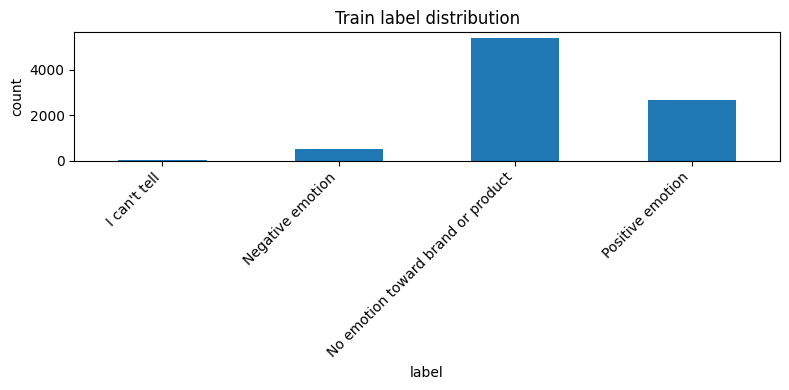

In [4]:
label_col = "is_there_an_emotion_directed_at_a_brand_or_product"
text_col = "tweet_text"
vc = train_df[label_col].value_counts(dropna=False)
print(vc)
edh.plot_label_counts(vc, "Train label distribution")


## Text length (train)

chars mean/median: 104.84258935848177 109.0
words mean/median: 17.750844102922343 18.0


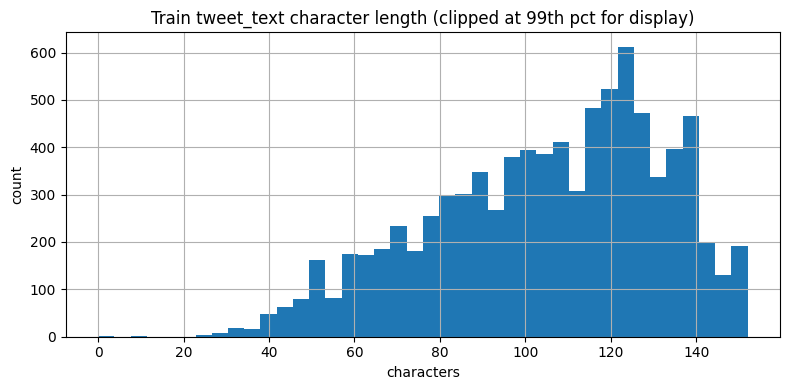

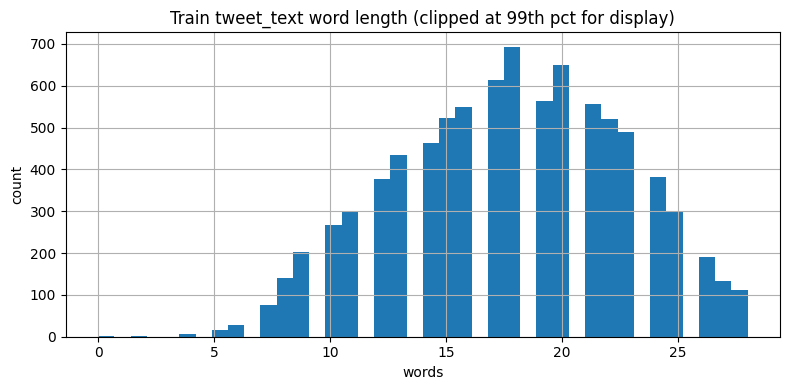

pattern stats (train): {'url_pct': np.float64(0.4890544946436889), 'mention_pct': np.float64(54.21518397764322), 'hashtag_pct': np.float64(99.93013507219376), 'emoji_pct': np.float64(0.0)}


In [5]:
char_len, word_len = edh.char_word_lengths(train_df[text_col])
print("chars mean/median:", float(char_len.mean()), float(char_len.median()))
print("words mean/median:", float(word_len.mean()), float(word_len.median()))
edh.plot_hist_length(char_len, "Train tweet_text character length", "characters")
edh.plot_hist_length(word_len, "Train tweet_text word length", "words")
print("pattern stats (train):", edh.text_pattern_stats(train_df[text_col]))


## Sample texts by class (train)

Up to 2 random examples per label.

In [6]:
rng = __import__("random").Random(42)
for lab in sorted(train_df[label_col].dropna().unique()):
    sub = train_df[train_df[label_col] == lab]
    k = min(2, len(sub))
    if k == 0:
        continue
    idx = rng.sample(list(sub.index), k=k)
    print("\n===", lab, "===")
    for i in idx:
        t = str(train_df.loc[i, text_col])[:280]
        print("-", repr(t))



=== I can't tell ===
- 'I am neither at #SXSW nor buying an iPad 2 today. I feel like my geek cred is basically gone.'
- "I won't be at #sxsw and I won't be in line to buy iPad 2.0 tomorrow. #notwinning."

=== Negative emotion ===
- 'Nope, seems no Google Circles launch today: {link} #sxsw'
- "And now, it won't pull from website to iPhone. Awesome. Glad I wasted that time. #festivalgenius #notsomuch #sxsw"

=== No emotion toward brand or product ===
- '@mention from Google taking the mic  #health2dev  #SXSW'
- 'Style X &amp; @mention - brethren #SXSW pop-ups! ://m.theatlantic.com/technology/archive/2011/03/apple-sets-up-temporary-megastore-at-sxsw/72296/'

=== Positive emotion ===
- '#Awesome - Google Maps 5.22 at #SXSW.  Great Job #Google.'
- 'Google Circles at #sxsw whoooooo {link}'


## Data quality (train)

In [7]:
char_len, word_len = edh.char_word_lengths(train_df[text_col])
short_pct = 100.0 * (word_len <= 2).mean()
dup_txt = edh.duplicate_text_pct(train_df[text_col])
print(f"≤2 words: {short_pct:.2f}%")
print(f"duplicate texts: {dup_txt:.2f}%")
non_str = (~train_df[text_col].map(lambda x: isinstance(x, str)) & train_df[text_col].notna()).sum()
print("non-string text cells:", int(non_str))


≤2 words: 0.02%
duplicate texts: 0.31%
non-string text cells: 0


## Schema & preprocessing notes

- Map emotion strings to a 3-class or multi-class target for cross-dataset training.
- Drop or stratify very short tweets.
- Test CSV has no labels — use only for inference or pseudo-labeling.
- Align encoding with `models/sentiment` preprocessing if combining with other corpora.

In [8]:
summary = {
    "dataset": "twitter_brand",
    "row_count_train": int(len(train_df)),
    "row_count_test": int(len(test_df)),
    "text_column_train": text_col,
    "text_column_test": "Tweet",
    "label_column": label_col,
    "label_space": str(sorted(train_df[label_col].dropna().unique().tolist())),
    "avg_word_count": float(edh.char_word_lengths(train_df[text_col])[1].mean()),
    "median_word_count": float(edh.char_word_lengths(train_df[text_col])[1].median()),
    "duplicate_text_pct": edh.duplicate_text_pct(train_df[text_col]),
    "null_pct": edh.null_fraction_df(train_df) * 100.0,
    "preprocessing": "Remap string labels to integers; clean URLs/mentions optional; test set label-free.",
}
path = edh.save_eda_summary("twitter_brand", summary, PROJECT_ROOT)
print("Saved summary:", path)


Saved summary: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/processed/eda_summaries/twitter_brand.json
